In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_squared_error
import yfinance as yf

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Input, Dropout

from statsmodels.tsa.statespace.sarimax import SARIMAX

In [15]:
df = pd.read_csv('vinamilk_stock.csv')

In [16]:
df.head(5)

,Date,Matched Price,Volume,Open Price,High Price,Low Price,Foreign Buy,Foreign Sell,Foreign Value
0,1/2/2020,81.78,352700,80.81,81.99,80.81,147810,95820,6.1
1,1/3/2020,82.06,625390,81.78,82.54,81.99,330020,9290,38.1
2,1/6/2020,81.43,495910,82.06,82.06,81.02,422986,304256,14.0
3,1/7/2020,82.19,459520,81.43,82.40,81.50,297110,27190,31.9
4,1/8/2020,82.40,837710,82.19,82.40,81.50,615220,51980,66.5


In [17]:
df.tail(5)

,Date,Matched Price,Volume,Open Price,High Price,Low Price,Foreign Buy,Foreign Sell,Foreign Value
1328,5/5/2025,56.9,4238300,57.5,57.6,56.9,187500,1189900,0.0
1329,5/6/2025,56.9,2502600,57.0,57.4,56.9,116000,577000,0.0
1330,5/7/2025,57.1,2789200,56.9,57.7,56.9,802800,794000,0.0
1331,5/8/2025,57.4,3262200,57.2,57.8,57.2,462200,844300,0.0
1332,5/9/2025,57.7,3832400,57.7,58.6,57.7,306900,856600,0.0


In [18]:
df_timeseries = df[['Date', 'Matched Price']]
df_timeseries = df_timeseries.set_index(['Date'])
df_timeseries.head()

,Matched Price
Date,
1/2/2020,81.78
1/3/2020,82.06
1/6/2020,81.43
1/7/2020,82.19
1/8/2020,82.40


<Axes: xlabel='Date'>

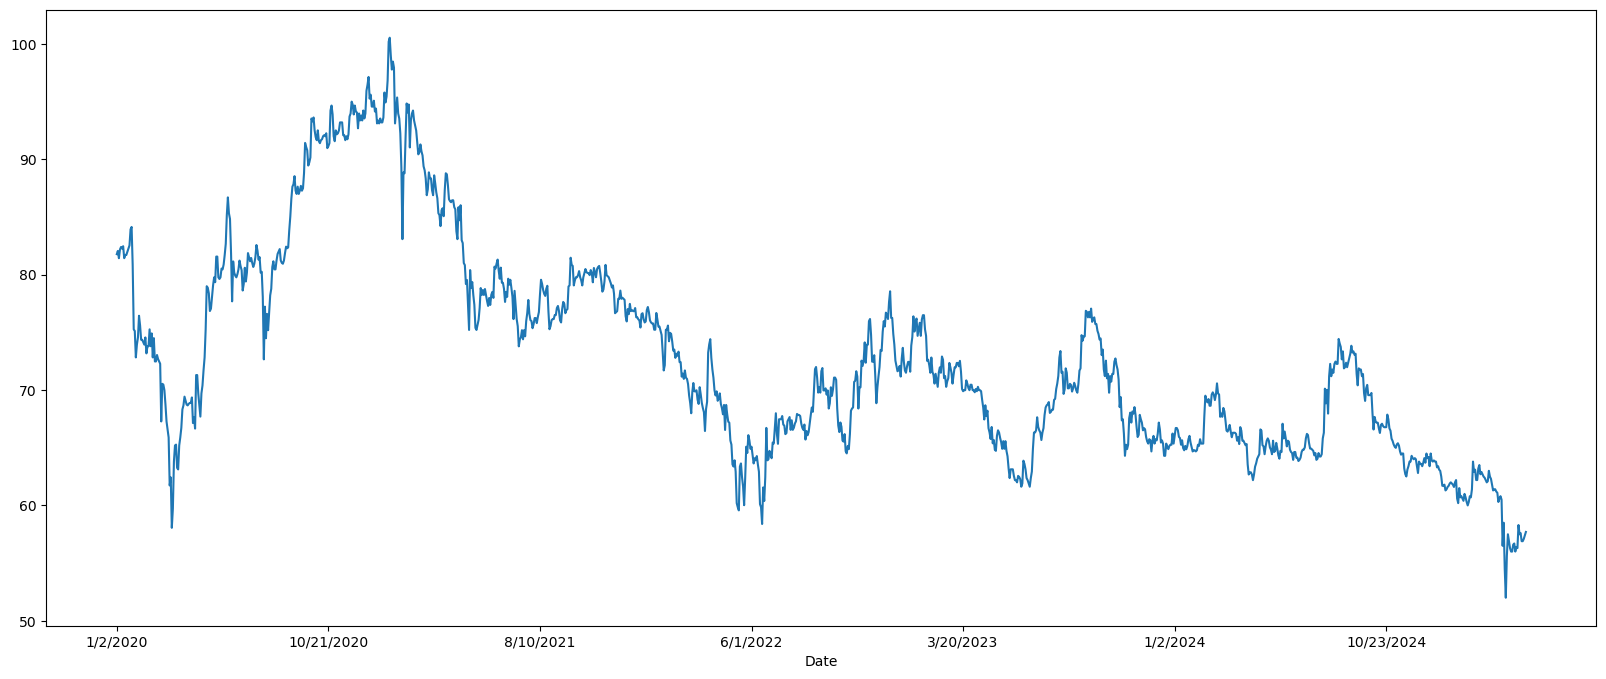

In [19]:
plt.rcParams['figure.figsize'] = (20, 8)
df_timeseries['Matched Price'].plot()

In [20]:
## 1 AR : 3 ngay du doan 1 ngay
def getXy(data, window_size = 3):
    n = len(data) - window_size
    dic = {}
    for i in range(window_size):
        dic[f'X{i}'] = data[i : n + i]
    
    df = pd.DataFrame(data = dic)
    df['y'] = data[window_size:]
    return df

In [21]:
window_size = 3
df_data = getXy(df_timeseries['Matched Price'].values, window_size)
#X.shape, y.shape

In [22]:
df_data.head()

,X0,X1,X2,y
0,81.78,82.06,81.43,82.19
1,82.06,81.43,82.19,82.40
2,81.43,82.19,82.40,82.26
3,82.19,82.40,82.26,82.47
4,82.40,82.26,82.47,81.43


In [23]:
X = df_data.drop(columns = 'y').values
y = df_data['y'].values

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.05, shuffle=False)

In [25]:
ar = LinearRegression()
ar.fit(X_train, y_train)
ar.score(X_train, y_train), ar.score(X_test, y_test)

(0.9844421066914201, 0.8161811987350869)

In [26]:
y_train_predict = ar.predict(X_train)
y_test_predict = ar.predict(X_test)
df_timeseries['PredictAR'] = np.concat(([np.nan] * window_size, y_train_predict, y_test_predict))

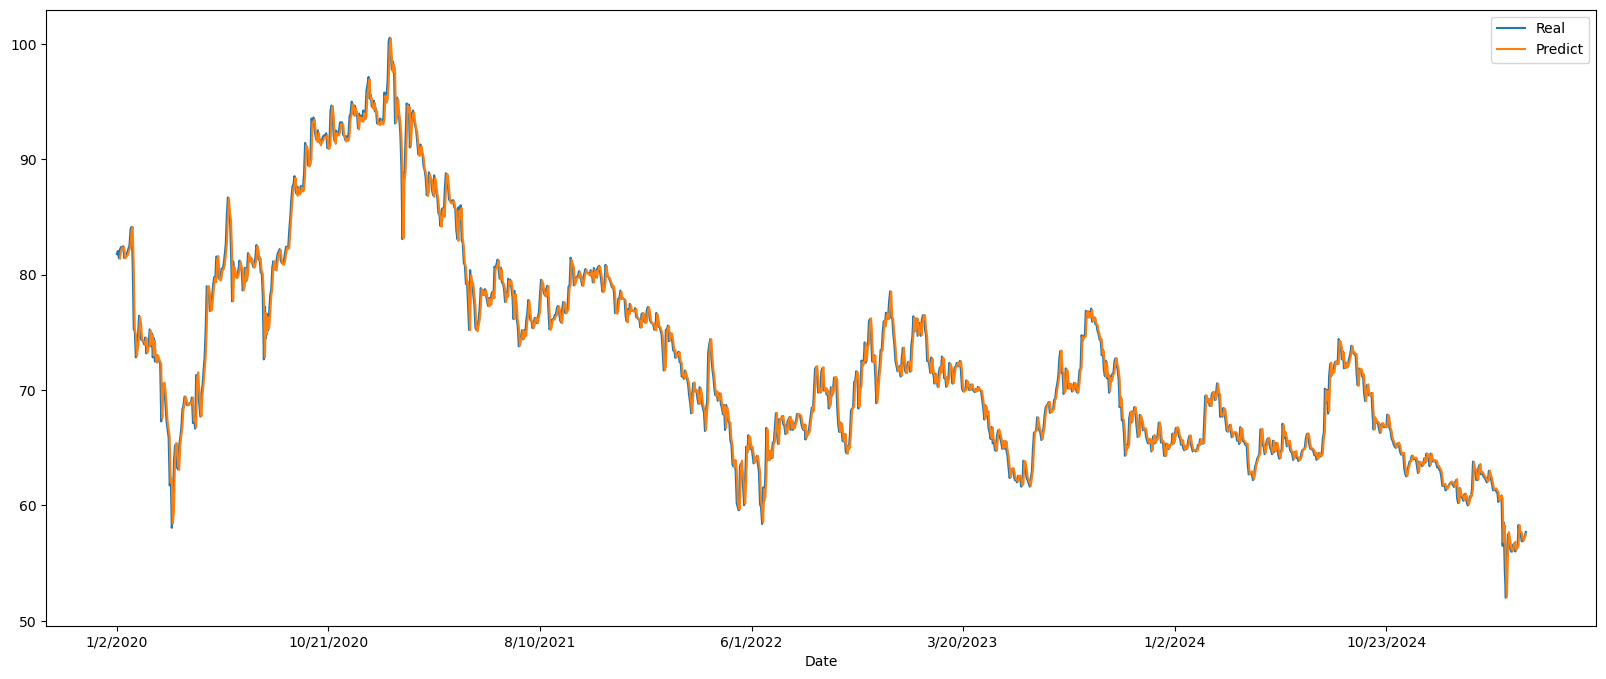

In [27]:
df_timeseries['Matched Price'].plot()
df_timeseries['PredictAR'].plot()

plt.legend(['Real', 'Predict'])
plt.show()

In [28]:
def ar_forcast(data, k = 1, window_size = 3):
    X = data[-window_size:]
    for i in range(k):
        
        y = ar.predict([X])
        print(X, y)
        X = np.concat((X[1:], y))
    return y

In [29]:
ar_forcast(df['Matched Price'].values, k = 3)

[57.1 57.4 57.7] [57.80262062]
[57.4        57.7        57.80262062] [57.91471825]
[57.7        57.80262062 57.91471825] [58.01528351]


array([58.01528351])

In [30]:
## 2 Random Forest
forest = RandomForestRegressor()
forest.fit(X_train, y_train)
forest.score(X_train, y_train), forest.score(X_test, y_test)

(0.997257457778917, -0.5854282112211775)

In [31]:
y_train_forest_predict = forest.predict(X_train)
y_test_forest_predict = forest.predict(X_test)

In [32]:
df_timeseries['PredictForest'] = np.concat(([np.nan] * window_size, y_train_predict, y_test_predict))
df_timeseries.head()

,Matched Price,PredictAR,PredictForest
Date,,,
1/2/2020,81.78,NaN,NaN
1/3/2020,82.06,NaN,NaN
1/6/2020,81.43,NaN,NaN
1/7/2020,82.19,81.403253,81.403253
1/8/2020,82.40,82.038423,82.038423


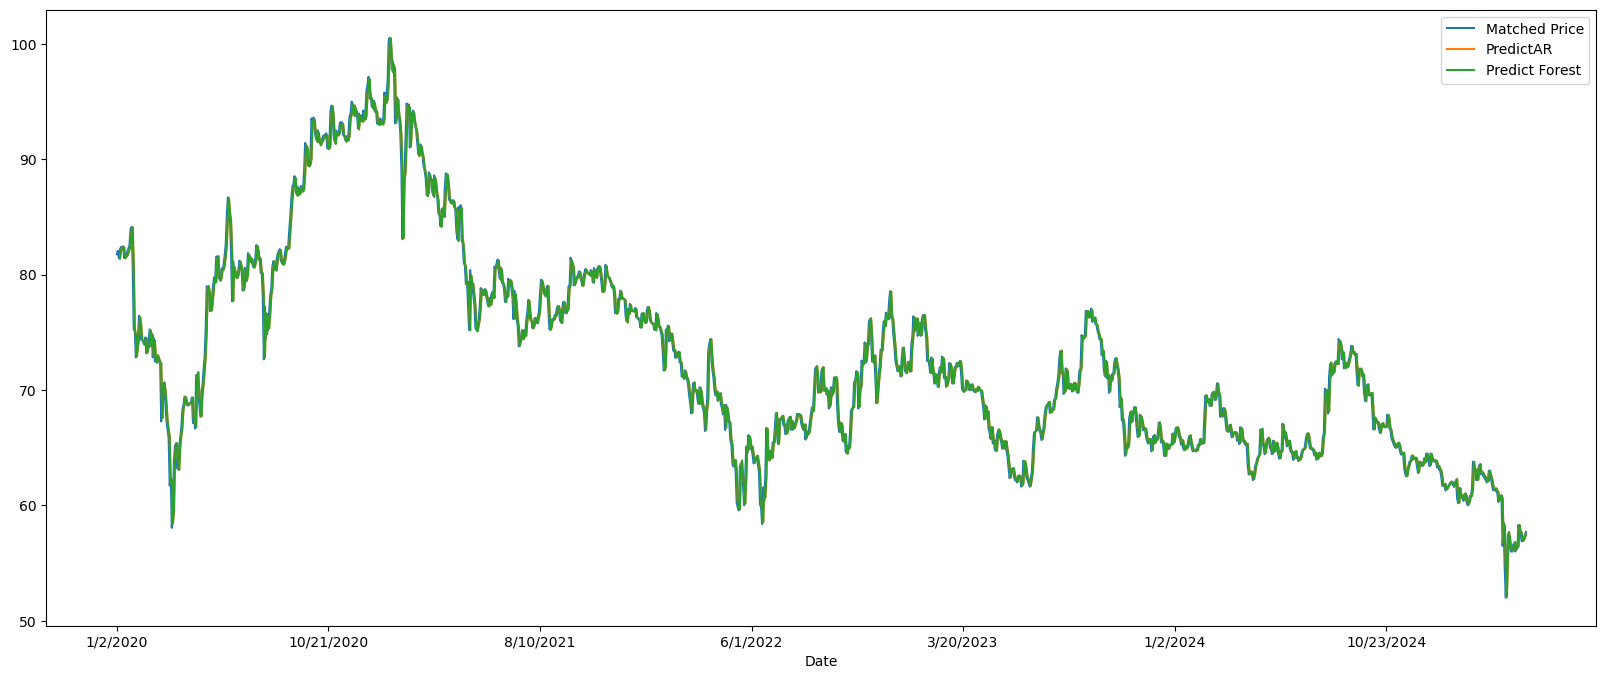

In [33]:
df_timeseries['Matched Price'].plot()
df_timeseries['PredictAR'].plot()
df_timeseries['PredictForest'].plot()

plt.legend(['Matched Price', 'PredictAR','Predict Forest'])
plt.show()

In [34]:
## 3 ARIMA
window_size = 3
X_arima = df_timeseries['Matched Price'].values
X_arima_train, X_arima_test = train_test_split(X_arima, test_size=0.1, shuffle=False)

# Fit ARIMA(p=1, d=2, q=1) (AR, I, AM)
print("\nFit mô hình ARIMA(3,0,1)...")
model = sm.tsa.ARIMA(X_arima_train, order=(window_size, 0, 1))
arima = model.fit()

print("\nSummary của mô hình:")
print(arima.summary())


Fit mô hình ARIMA(3,0,1)...

Summary của mô hình:
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1199
Model:                 ARIMA(3, 0, 1)   Log Likelihood               -1840.577
Date:                Sun, 11 May 2025   AIC                           3693.155
Time:                        21:22:01   BIC                           3723.690
Sample:                             0   HQIC                          3704.658
                               - 1199                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         74.1173      3.727     19.886      0.000      66.812      81.422
ar.L1          0.6510      0.349      1.863      0.062      -0.034       1.336
a

In [35]:
arima_pred = arima.predict(start=1, end=X_arima.shape[0])
arima_pred.shape, X_arima_train.shape, X_arima_test.shape

((1333,), (1199,), (134,))

In [36]:
# 3  SARIMA 
# Fit model with seasonal order (1,1,1,12) - monthly seasonality assumed

sarima_model = SARIMAX(X_arima_train, order=(1, 1, 1), seasonal_order=(1, 1, 1, 4))
sarima_fit = sarima_model.fit(disp=False)
sarima_fit.summary()

c:\ProgramData\anaconda3\envs\ml-anaconda-r-python-env\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\ProgramData\anaconda3\envs\ml-anaconda-r-python-env\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                     
=========================================================================================
Dep. Variable:                                 y   No. Observations:                 1199
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 4)   Log Likelihood               -1841.275
Date:                           Sun, 11 May 2025   AIC                           3692.550
Time:                                   21:22:02   BIC                           3717.975
Sample:                                        0   HQIC                          3702.130
                                          - 1199                                         
Covariance Type:                             opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.6914      0.146     -4.750      0.000      -0.977      -0.406
ma.L1          0.6185      0.153      4.054      0.000       0.319       0.917
ar.S.L4       -0.0984      0.027     -3.670      0.000      -0.151      -0.046
ma.S.L4       -0.9999      0.919     -1.088      0.277      -2.801       0.801
sigma2         1.2545      1.152      1.089      0.276      -1.003       3.512
===================================================================================
Ljung-Box (L1) (Q):                   0.27   Jarque-Bera (JB):               927.29
Prob(Q):                              0.60   Prob(JB):                         0.00
Heteroskedasticity (H):               0.33   Skew:                             0.12
Prob(H) (two-sided):                  0.00   Kurtosis:                         7.31
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [37]:
pred = sarima_fit.predict(start=1, end=X_arima.shape[0])
pred.shape, X_arima_train.shape, X_arima_test.shape

((1333,), (1199,), (134,))

In [38]:
# 4 RNN model
model = Sequential([
    Input(shape=(window_size, 1)),
    SimpleRNN(100, return_sequences=True),
    Dropout(0.2),
    SimpleRNN(50, activation='tanh'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=20, validation_data=(X_test, y_test), batch_size=32, verbose=1)
model.summary()

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 4995.6885 - val_loss: 2626.6299
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4231.6626 - val_loss: 2398.6899
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3936.7986 - val_loss: 2196.0872
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3686.6213 - val_loss: 2009.6639
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3436.8376 - val_loss: 1836.4298
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3190.3770 - val_loss: 1674.6206
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2982.3010 - val_loss: 1523.8971
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2781.1797 - val_loss: 1383.3668
Epoch 9/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2570.5771 - val_loss: 1252.1211
Epoch 10/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2430.8352 - val_loss: 1129.9053
Epoch 11/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2300.3206 - val_loss: 1016.2832
Epoch 1

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_2 (SimpleRNN)        │ (None, 3, 100)         │        10,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 3, 100)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ (None, 50)             │         7,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,405 (208.62 KB)

 Trainable params: 17,801 (69.54 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 35,604 (139.08 KB)

In [39]:
model.evaluate(X_train, y_train), model.evaluate(X_test, y_test)

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1342.3173 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 337.8047


(1062.716064453125, 320.8961486816406)

In [40]:
# Predict
y_test_pred = model.predict(X_test)
y_train_pred = model.predict(X_train)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


In [41]:
r2_score(y_test, y_test_pred), r2_score(y_train, y_train_pred)

(-44.88684500102221, -12.72297003022769)